# Machine Learning Model for Loan Approval

## Executive Summary

FinTech Innovations can improve consistency and speed in loan screening by using a supervised classification model to predict whether an application should be approved. I selected a classification approach because the operational decision is binary: approve for further processing or deny/refer for manual review. The model is evaluated with both predictive metrics and a custom business-cost metric because the error costs are asymmetric: approving a bad loan is estimated to cost $50,000, while denying a good loan is estimated to lose $8,000 in profit.

The final solution uses a scikit-learn `Pipeline` and `ColumnTransformer` with median imputation and scaling for numeric features, mode imputation and one-hot encoding for categorical features, and a tuned logistic regression classifier. Logistic regression was selected because it delivered the strongest cross-validated ROC-AUC among the models tested while remaining interpretable enough for a regulated lending context.

A default 0.50 approval threshold is useful for general accuracy and recall, but a higher threshold is more aligned to the business cost structure. In final testing, the tuned model kept a strong ROC-AUC near 0.97 and the cost-sensitive threshold substantially reduced costly false approvals compared with the standard threshold. The recommendation is to deploy the model first as a decision-support score with manual review around borderline cases, monitor outcomes by applicant segment, and recalibrate thresholds as real default outcomes accumulate.

## 1. Business Understanding

FinTech Innovations currently supports a loan approval process that depends heavily on manual loan-officer review. Manual review can incorporate human judgment, but it also creates inconsistent decisions, slower application turnaround, and limited ability to systematically learn from historical outcomes. A machine learning workflow can make the first-pass screening process more consistent while still allowing loan officers to override or review complex cases.

**Stakeholders and needs**

- Applicants need fair, timely, and explainable decisions.
- Loan officers need a reliable risk signal that reduces repetitive review work without hiding important drivers.
- Risk management needs fewer costly approvals of high-risk applicants.
- Bank partners and compliance teams need transparent documentation, repeatable preprocessing, and evidence that the model is monitored for bias.
- Executives need a model that improves portfolio economics without damaging customer experience.

**Error-cost implications**

In this notebook, the positive class is `LoanApproved = 1`, meaning the applicant is treated as creditworthy/approvable based on the historical label. A false positive is therefore an applicant predicted for approval when the historical label was denial; this is treated as the expensive error because it can correspond to approving a bad loan. A false negative is an applicant predicted for denial when the historical label was approval; this maps to missed profit from denying a good loan.

Business cost formula used throughout:

`business_cost = 50000 * false_positives + 8000 * false_negatives`

Because false positives are more than six times as expensive as false negatives, accuracy alone is not sufficient. I use ROC-AUC to measure ranking quality, precision and recall to understand approval tradeoffs, and a custom business-cost metric to translate errors into dollars.

**Modeling choice**

I use a classification approach instead of regression because the workflow goal is to support or automate the approval decision. The dataset also contains a `RiskScore`, but using it as a target would make the result less directly aligned with the final business action. I exclude `RiskScore` from the features because it is likely an existing derived risk measure and would create target leakage for an approval model.

**Success criteria**

- Beat a majority-class baseline on ROC-AUC, F1, and business cost.
- Use at least two metrics: ROC-AUC and the custom dollar-cost metric, with precision/recall added for interpretation.
- Prefer an interpretable model unless a more complex model materially improves business results.
- Keep all preprocessing inside a reproducible pipeline.

In [1]:
# Core imports
import os
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)

data_candidates = [
    Path("financial_loan_data.csv"),
    Path.cwd() / "financial_loan_data.csv",
    Path("/Users/savagebata/Downloads/financial_loan_data.csv"),
]
DATA_PATH = next((p for p in data_candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Place financial_loan_data.csv next to this notebook or update DATA_PATH.")

df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


## 2. Data Understanding

The dataset has 20,000 historical loan applications and 35 columns. It includes demographic attributes, employment and education attributes, credit behavior, balance sheet information, loan terms, a binary approval label, and a risk score. The data contains a few intentionally messy elements that need cleaning, most notably `AnnualIncome` stored as currency text and missing values in `MaritalStatus`, `EducationLevel`, and `SavingsAccountBalance`.

To reduce leakage, I treat the following as unavailable or post-underwriting outputs for the approval model: `RiskScore`, `BaseInterestRate`, `InterestRate`, `MonthlyLoanPayment`, and `TotalDebtToIncomeRatio`. This makes the model more realistic for pre-approval screening.

In [2]:
df = df_raw.copy()

# Clean a messy currency field into a numeric value.
df["AnnualIncome"] = (
    df["AnnualIncome"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

target = "LoanApproved"
leakage_or_post_decision = [
    "RiskScore",
    "BaseInterestRate",
    "InterestRate",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio",
]

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print("\nTarget distribution:")
display(df[target].value_counts().rename({0: "Denied", 1: "Approved"}).to_frame("count"))
display((df[target].value_counts(normalize=True).rename({0: "Denied", 1: "Approved"}) * 100).round(2).to_frame("percent"))

missing = (
    df.isna().sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(2)
display(missing)

display(df.describe(include="all").T.head(35))

Rows: 20,000
Columns: 35

Target distribution:


,count
LoanApproved,
Denied,15220
Approved,4780


,percent
LoanApproved,
Denied,76.1
Approved,23.9


,missing_count,missing_percent
MaritalStatus,1331,6.65
EducationLevel,901,4.50
SavingsAccountBalance,572,2.86


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
AnnualIncome,20000.0,NaN,NaN,NaN,59161.47355,40350.845168,15000.0,31679.0,48566.0,74391.0,485341.0
CreditScore,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
EmploymentStatus,20000,3,Employed,17036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationLevel,19099,5,Bachelor,5804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,20000.0,NaN,NaN,NaN,17.52275,11.316836,0.0,9.0,17.0,25.0,61.0
LoanAmount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
LoanDuration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
MaritalStatus,18669,4,Married,9370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfDependents,20000.0,NaN,NaN,NaN,1.5173,1.386325,0.0,0.0,1.0,2.0,5.0


In [3]:
numeric_features_all = df.drop(columns=[target]).select_dtypes(include=np.number).columns.tolist()
categorical_features_all = df.drop(columns=[target]).select_dtypes(exclude=np.number).columns.tolist()

feature_catalog = pd.DataFrame({
    "feature": numeric_features_all + categorical_features_all,
    "type": ["numeric"] * len(numeric_features_all) + ["categorical"] * len(categorical_features_all),
    "model_use": [
        "excluded_leakage_or_post_decision" if f in leakage_or_post_decision else "candidate_feature"
        for f in numeric_features_all + categorical_features_all
    ],
})
display(feature_catalog)

,feature,type,model_use
0,Age,numeric,candidate_feature
1,AnnualIncome,numeric,candidate_feature
2,CreditScore,numeric,candidate_feature
3,Experience,numeric,candidate_feature
4,LoanAmount,numeric,candidate_feature
5,LoanDuration,numeric,candidate_feature
6,NumberOfDependents,numeric,candidate_feature
7,MonthlyDebtPayments,numeric,candidate_feature
8,CreditCardUtilizationRate,numeric,candidate_feature
9,NumberOfOpenCreditLines,numeric,candidate_feature


### Exploratory Visualizations and Findings

The EDA below checks target imbalance, missingness, distribution shape, outliers, feature relationships, and approval differences across major segments. Several numeric variables are right-skewed, especially income, balances, assets, liabilities, and net worth. The target is imbalanced: denials are the majority class. This means a naive classifier can look accurate while failing to identify applicants who should be approved.

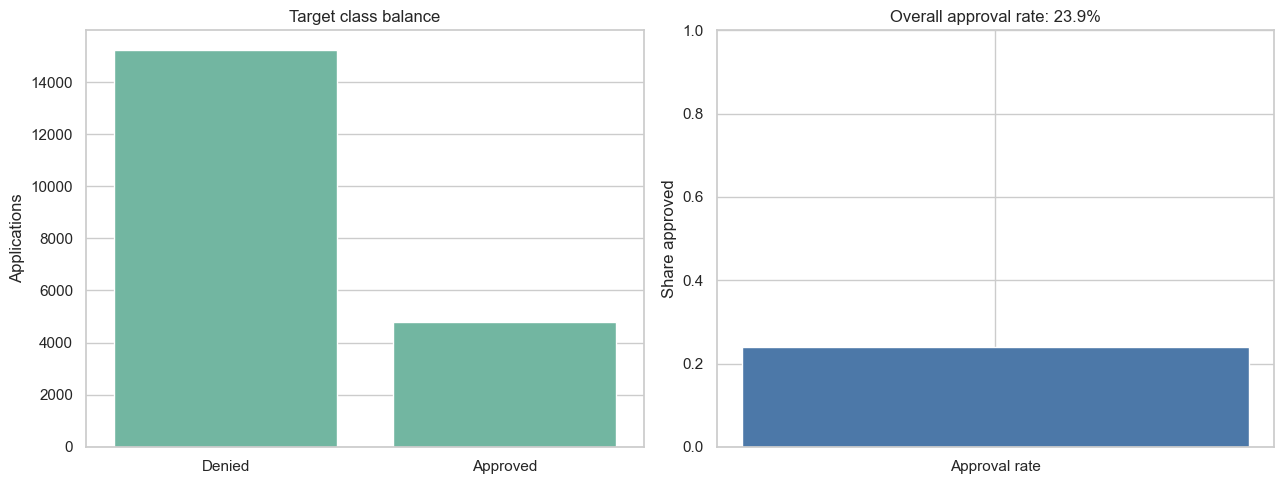

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=df, x=target, ax=axes[0])
axes[0].set_title("Target class balance")
axes[0].set_xticklabels(["Denied", "Approved"])
axes[0].set_xlabel("")
axes[0].set_ylabel("Applications")

approval_rate = df[target].mean()
axes[1].bar(["Approval rate"], [approval_rate], color="#4C78A8")
axes[1].set_ylim(0, 1)
axes[1].set_title(f"Overall approval rate: {approval_rate:.1%}")
axes[1].set_ylabel("Share approved")
plt.tight_layout()
plt.show()

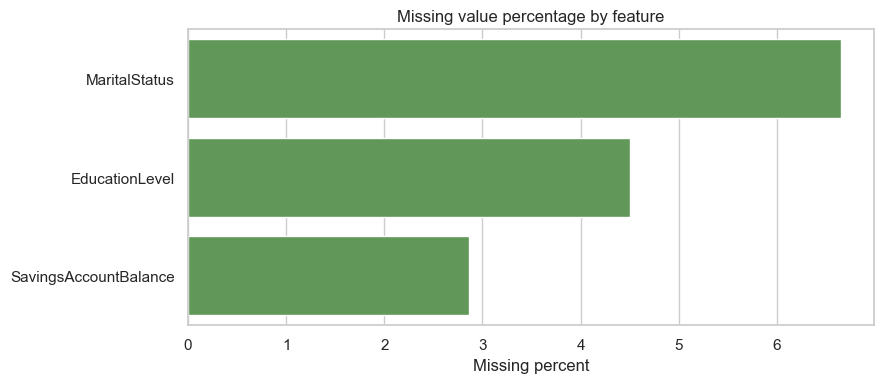

In [5]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(9, 4))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="#59A14F")
plt.title("Missing value percentage by feature")
plt.xlabel("Missing percent")
plt.ylabel("")
plt.tight_layout()
plt.show()

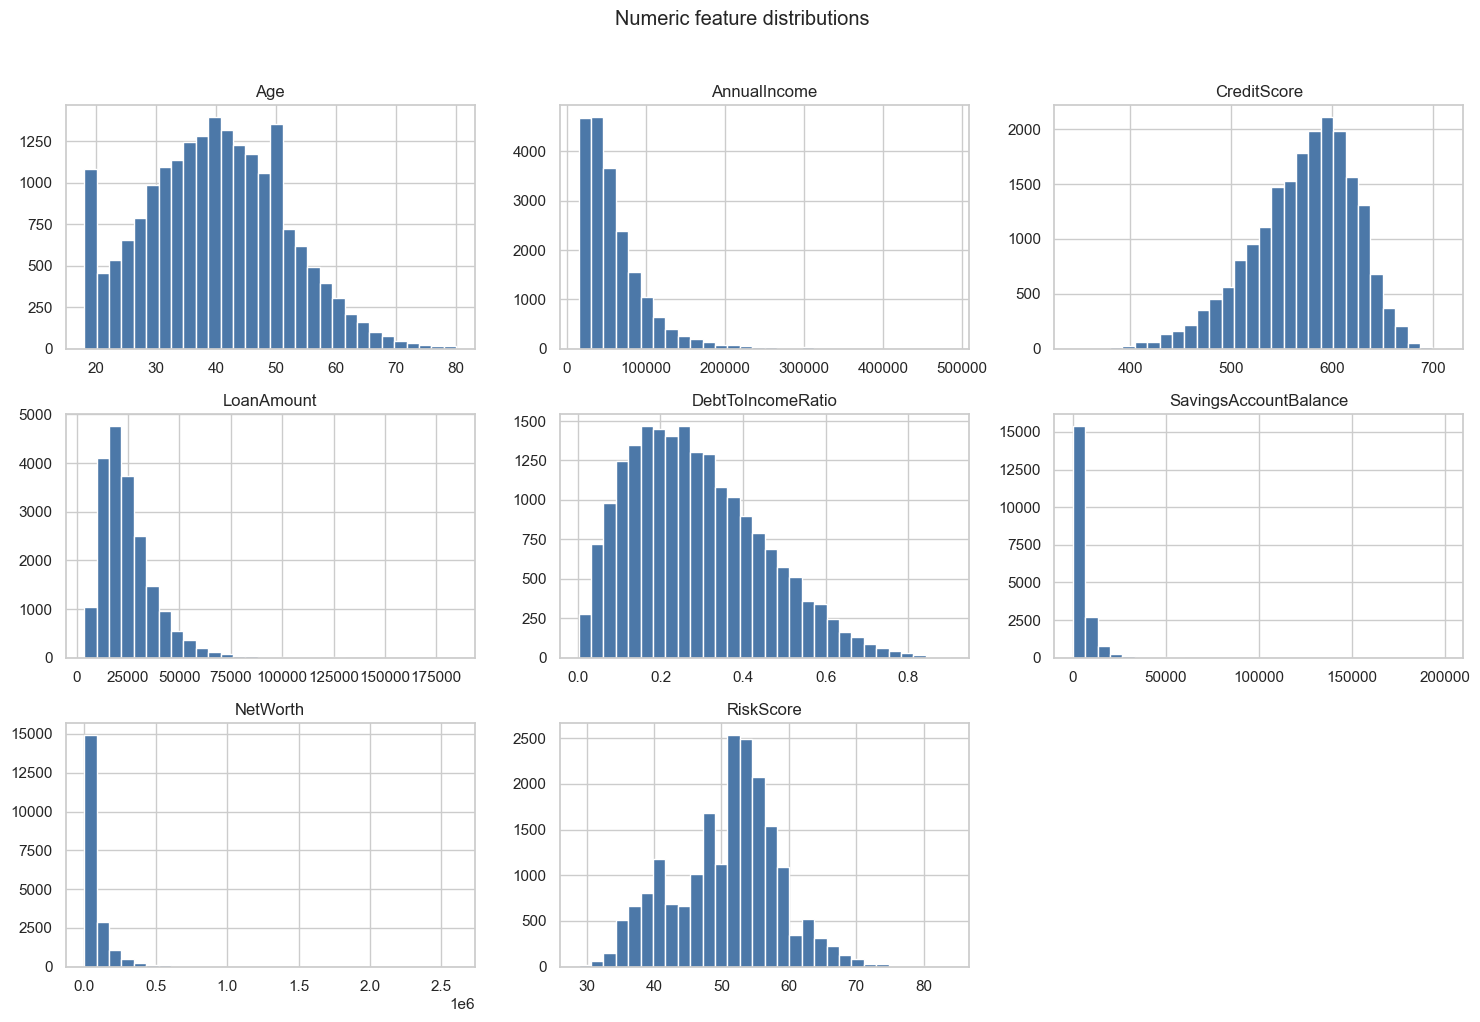

In [6]:
key_numeric = [
    "Age",
    "AnnualIncome",
    "CreditScore",
    "LoanAmount",
    "DebtToIncomeRatio",
    "SavingsAccountBalance",
    "NetWorth",
    "RiskScore",
]
df[key_numeric].hist(bins=30, figsize=(15, 10), color="#4C78A8", edgecolor="white")
plt.suptitle("Numeric feature distributions", y=1.02)
plt.tight_layout()
plt.show()

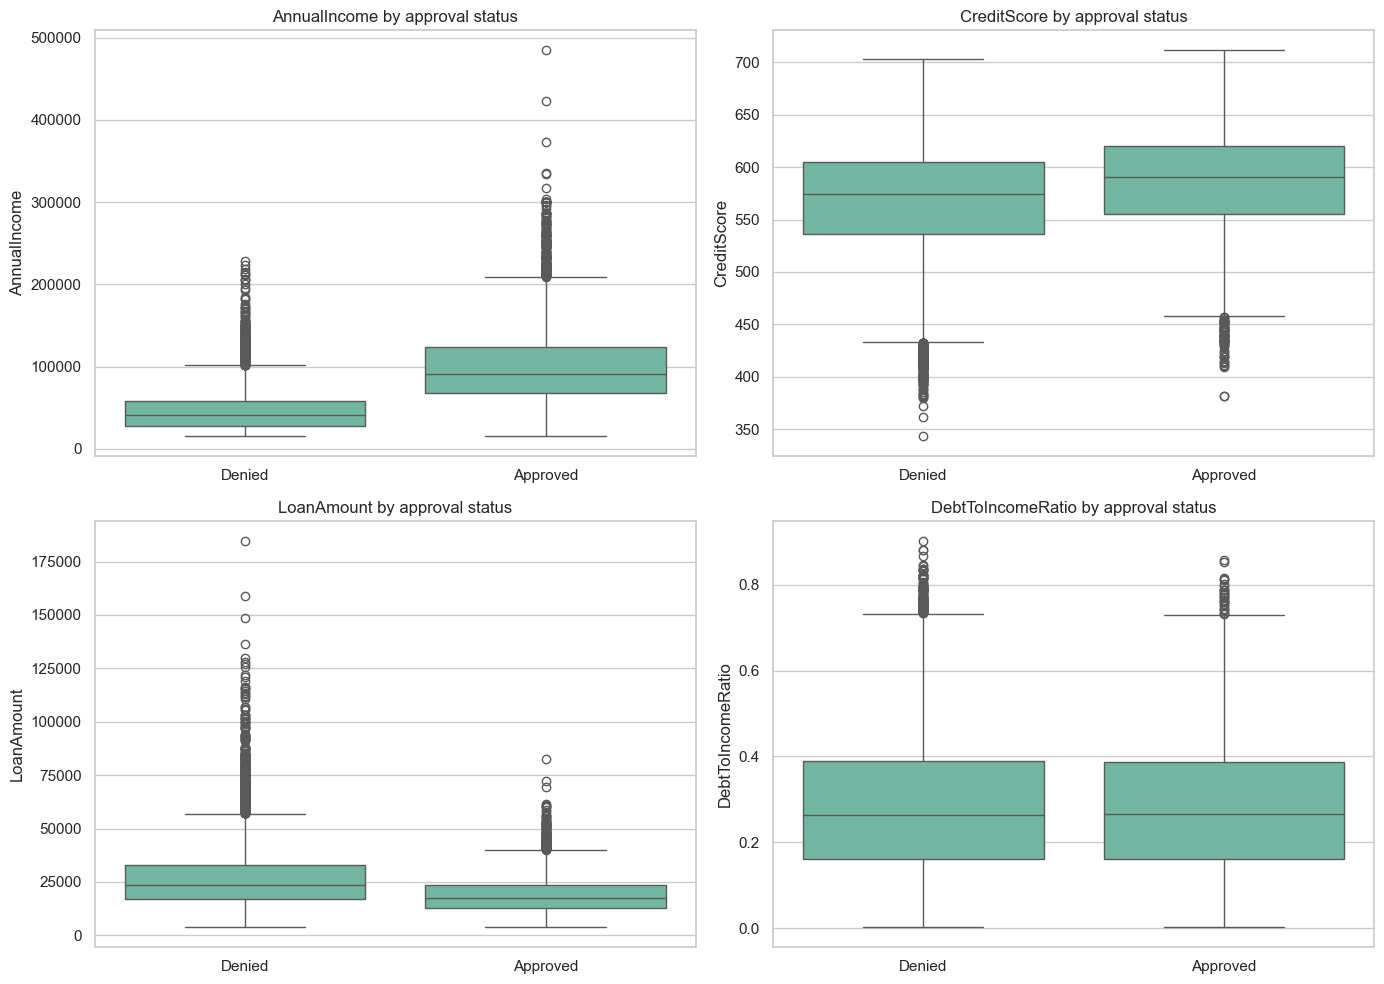

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
box_features = ["AnnualIncome", "CreditScore", "LoanAmount", "DebtToIncomeRatio"]
for ax, feature in zip(axes.ravel(), box_features):
    sns.boxplot(data=df, x=target, y=feature, ax=ax)
    ax.set_title(f"{feature} by approval status")
    ax.set_xticklabels(["Denied", "Approved"])
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

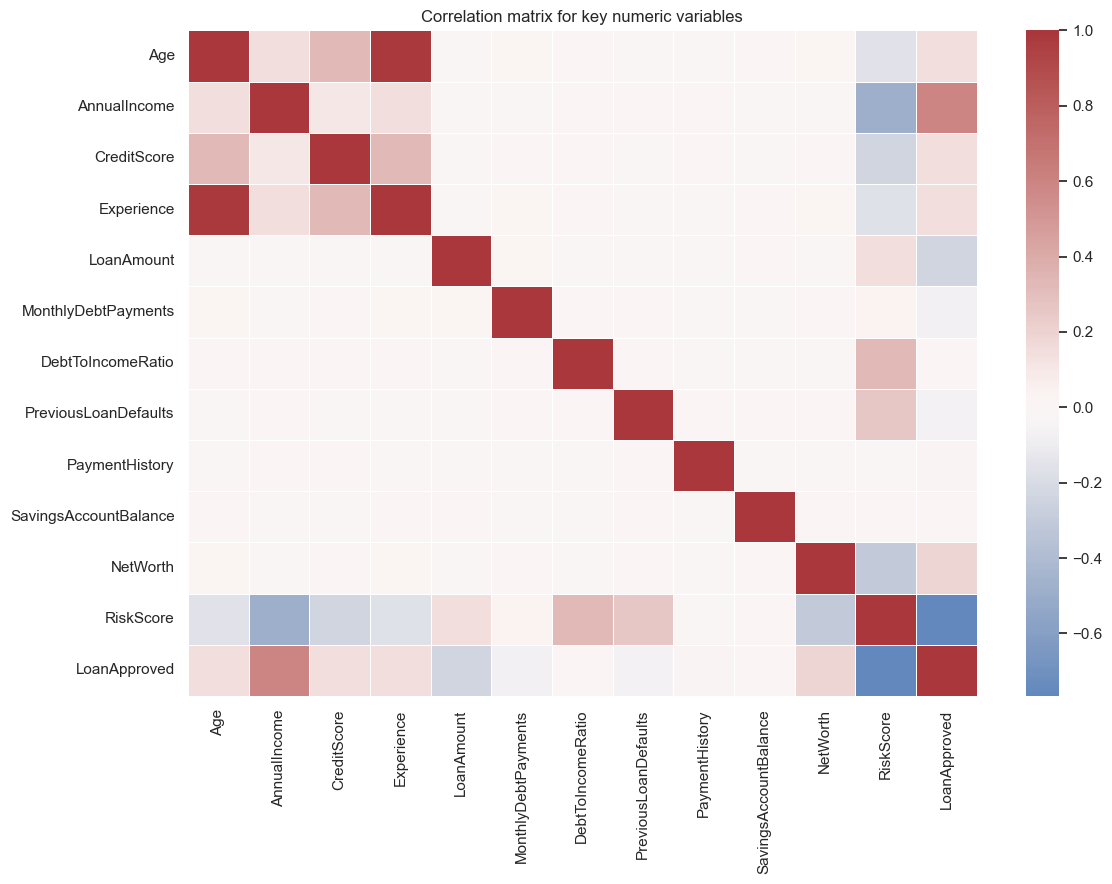

In [8]:
corr_cols = [
    "Age",
    "AnnualIncome",
    "CreditScore",
    "Experience",
    "LoanAmount",
    "MonthlyDebtPayments",
    "DebtToIncomeRatio",
    "PreviousLoanDefaults",
    "PaymentHistory",
    "SavingsAccountBalance",
    "NetWorth",
    "RiskScore",
    target,
]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="vlag", center=0, annot=False, linewidths=0.5)
plt.title("Correlation matrix for key numeric variables")
plt.tight_layout()
plt.show()

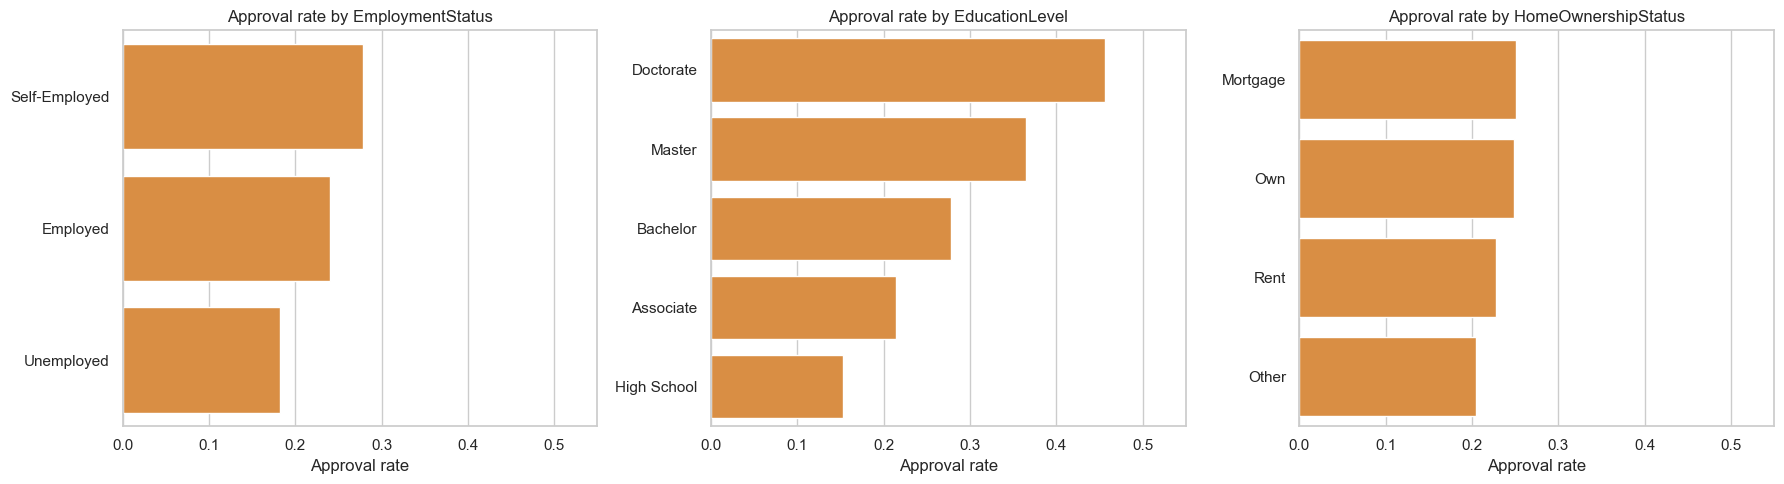

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feature in zip(axes, ["EmploymentStatus", "EducationLevel", "HomeOwnershipStatus"]):
    rates = df.groupby(feature)[target].mean().sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, color="#F28E2B")
    ax.set_title(f"Approval rate by {feature}")
    ax.set_xlabel("Approval rate")
    ax.set_ylabel("")
    ax.set_xlim(0, max(0.55, rates.max() + 0.05))
plt.tight_layout()
plt.show()

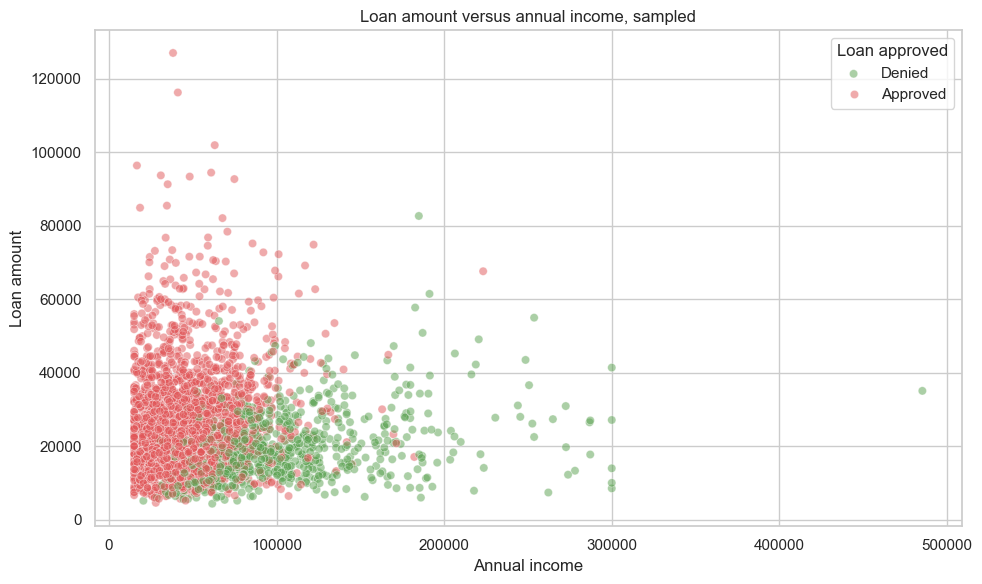

In [10]:
plt.figure(figsize=(10, 6))
sample = df.sample(3000, random_state=RANDOM_STATE)
sns.scatterplot(
    data=sample,
    x="AnnualIncome",
    y="LoanAmount",
    hue=target,
    alpha=0.5,
    palette={0: "#E15759", 1: "#59A14F"},
)
plt.title("Loan amount versus annual income, sampled")
plt.xlabel("Annual income")
plt.ylabel("Loan amount")
plt.legend(title="Loan approved", labels=["Denied", "Approved"])
plt.tight_layout()
plt.show()

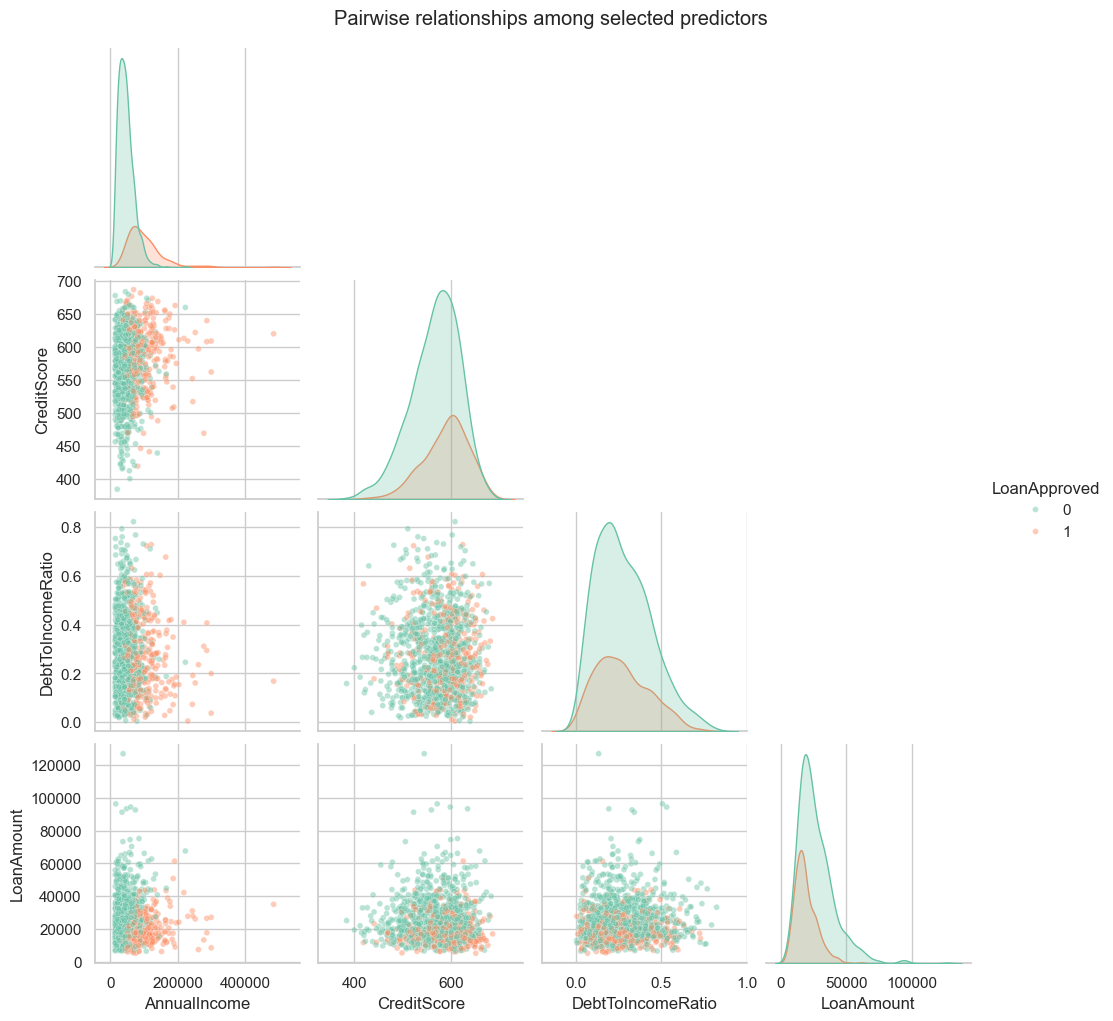

In [11]:
pair_cols = ["AnnualIncome", "CreditScore", "DebtToIncomeRatio", "LoanAmount", target]
pair_sample = df[pair_cols].sample(1200, random_state=RANDOM_STATE)
sns.pairplot(pair_sample, hue=target, corner=True, plot_kws={"alpha": 0.45, "s": 18})
plt.suptitle("Pairwise relationships among selected predictors", y=1.02)
plt.show()

In [12]:
# Statistical relationship checks for key variables.
approved = df.loc[df[target] == 1]
denied = df.loc[df[target] == 0]
tests = []
for feature in ["CreditScore", "AnnualIncome", "DebtToIncomeRatio", "LoanAmount", "RiskScore"]:
    stat, p_value = stats.mannwhitneyu(approved[feature].dropna(), denied[feature].dropna(), alternative="two-sided")
    tests.append({
        "feature": feature,
        "approved_median": approved[feature].median(),
        "denied_median": denied[feature].median(),
        "mann_whitney_p_value": p_value,
    })
display(pd.DataFrame(tests).sort_values("mann_whitney_p_value"))

,feature,approved_median,denied_median,mann_whitney_p_value
1,AnnualIncome,91269.5000,40557.500000,0.000000e+00
4,RiskScore,40.0000,54.000000,0.000000e+00
3,LoanAmount,17336.5000,23566.000000,2.654980e-296
0,CreditScore,591.0000,574.000000,1.041121e-90
2,DebtToIncomeRatio,0.2666,0.263107,8.516968e-01


**EDA interpretation**

- The target is imbalanced, with approvals representing roughly one quarter of applications.
- `RiskScore` is strongly separated by approval status, which is expected, but it should not be used as a predictor for a new approval model because it is a derived risk output.
- Approved applicants generally show stronger credit profiles: higher credit scores, lower debt burden, and stronger financial capacity.
- Several financial variables are skewed and contain outliers. Median imputation is appropriate for numeric missing values because it is robust to outliers.
- Missing values are concentrated in a small set of fields. I keep those observations and impute rather than dropping rows, which preserves sample size and avoids making missingness itself a silent filter.
- Potential feature engineering opportunities include affordability ratios, missingness indicators, and nonlinear bins for credit score or income. For this lab, I keep the pipeline transparent and avoid over-engineering.

## 3. Data Preparation

The preprocessing pipeline follows the rubric requirement to use `ColumnTransformer` and `Pipeline`.

- Numeric features: median imputation plus standard scaling. Scaling is important for logistic regression coefficients and harmless for the tree baseline comparisons used here.
- Categorical features: most-frequent imputation plus one-hot encoding with `handle_unknown="ignore"` so unseen categories do not break scoring.
- Leakage controls: the model excludes `RiskScore`, interest-rate fields, monthly payment, and total debt-to-income ratio because these are likely derived during or after underwriting.

In [13]:
y = df[target]
X = df.drop(columns=[target] + leakage_or_post_decision)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows: {len(X_test):,}")
print(f"Numeric candidate features: {len(numeric_features)}")
print(f"Categorical candidate features: {len(categorical_features)}")
print("Categorical columns:", categorical_features)

Training rows: 16,000
Testing rows: 4,000
Numeric candidate features: 23
Categorical candidate features: 6
Categorical columns: ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


## 4. Modeling

I compare three model algorithms that represent different complexity and interpretability tradeoffs:

- Logistic regression: highly interpretable, strong baseline for regulated settings.
- Decision tree: simple nonlinear model that is easy to explain but can overfit.
- Random forest: stronger nonlinear ensemble, less transparent than a single tree or logistic regression.

The dummy classifier is included only as a baseline. Cross-validation uses stratified folds to preserve the approval/denial mix.

In [14]:
FALSE_APPROVAL_COST = 50_000
FALSE_DENIAL_COST = 8_000

def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fp * FALSE_APPROVAL_COST + fn * FALSE_DENIAL_COST

def negative_cost_per_application(y_true, y_pred):
    return -business_cost(y_true, y_pred) / len(y_true)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "neg_business_cost_per_app": make_scorer(negative_cost_per_application),
}

models = {
    "Dummy majority baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=80,
        max_depth=10,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
comparison_rows = []

for name, estimator in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])
    model_scoring = scoring if name != "Dummy majority baseline" else {
        k: v for k, v in scoring.items() if k != "roc_auc"
    }
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=model_scoring,
        n_jobs=1,
        error_score="raise",
    )
    row = {"model": name}
    for metric in model_scoring:
        row[metric] = scores[f"test_{metric}"].mean()
    comparison_rows.append(row)

comparison = pd.DataFrame(comparison_rows)
comparison["business_cost_per_app"] = -comparison["neg_business_cost_per_app"]
comparison = comparison.drop(columns=["neg_business_cost_per_app"])
display(comparison.sort_values("business_cost_per_app"))

,model,accuracy,precision,recall,f1,roc_auc,business_cost_per_app
0,Dummy majority baseline,0.761000,0.000000,0.000000,0.000000,NaN,1912.000
1,Logistic Regression,0.909437,0.756767,0.915533,0.828572,0.974230,3680.250
3,Random Forest,0.870562,0.676452,0.879706,0.764724,0.953246,5264.375
2,Decision Tree,0.845625,0.627696,0.872905,0.730136,0.924856,6443.000


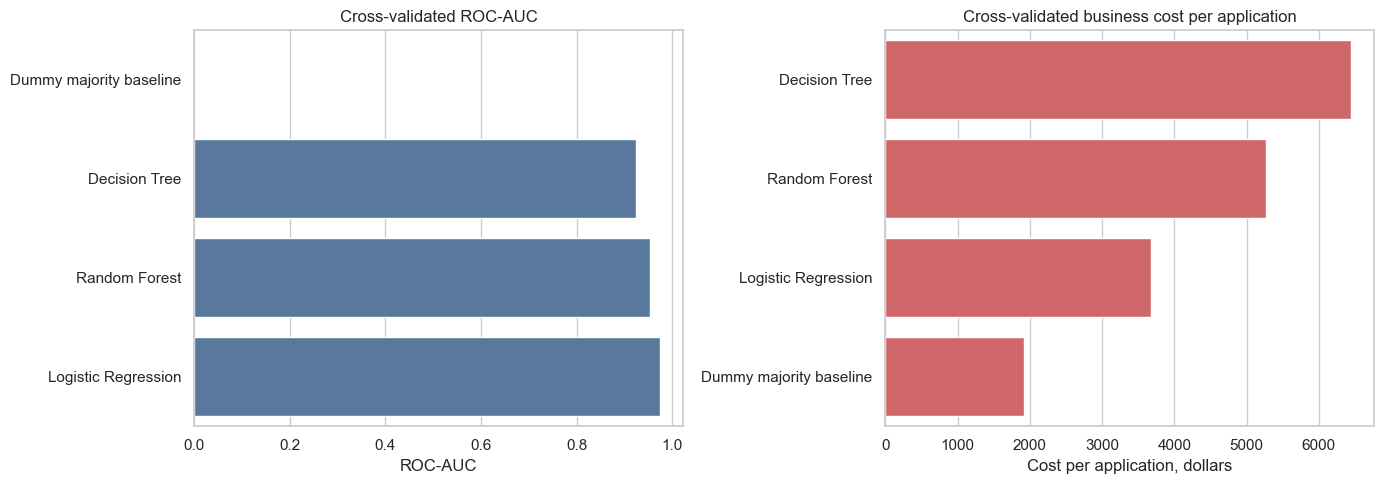

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=comparison.sort_values("roc_auc", na_position="first"),
    y="model",
    x="roc_auc",
    ax=axes[0],
    color="#4C78A8",
)
axes[0].set_title("Cross-validated ROC-AUC")
axes[0].set_xlabel("ROC-AUC")
axes[0].set_ylabel("")

sns.barplot(
    data=comparison.sort_values("business_cost_per_app", ascending=False),
    y="model",
    x="business_cost_per_app",
    ax=axes[1],
    color="#E15759",
)
axes[1].set_title("Cross-validated business cost per application")
axes[1].set_xlabel("Cost per application, dollars")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Hyperparameter Tuning

Logistic regression is the final model family because it provides the best combination of ranking performance, business cost, speed, and interpretability. I tune regularization strength and class weighting with `GridSearchCV`. The refit metric is ROC-AUC because it measures the model's ability to rank risk across possible thresholds. After selecting the model, I tune the classification threshold separately using the business-cost function.

In [16]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, solver="liblinear")),
])

param_grid = {
    "model__C": [0.05, 0.10, 0.50, 1.00, 2.00],
    "model__penalty": ["l1", "l2"],
    "model__class_weight": [None, "balanced"],
}

grid_search = GridSearchCV(
    logistic_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=1,
    return_train_score=True,
    error_score="raise",
)

grid_search.fit(X_train, y_train)
print("Best parameters:")
print(grid_search.best_params_)
print(f"Best cross-validated ROC-AUC: {grid_search.best_score_:.4f}")

cv_results = (
    pd.DataFrame(grid_search.cv_results_)
    .sort_values("rank_test_roc_auc")
    [[
        "rank_test_roc_auc",
        "mean_test_roc_auc",
        "mean_test_f1",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_neg_business_cost_per_app",
        "param_model__C",
        "param_model__penalty",
        "param_model__class_weight",
    ]]
    .head(10)
)
cv_results["business_cost_per_app"] = -cv_results["mean_test_neg_business_cost_per_app"]
display(cv_results.drop(columns=["mean_test_neg_business_cost_per_app"]))

Best parameters:
{'model__C': 0.5, 'model__class_weight': 'balanced', 'model__penalty': 'l1'}
Best cross-validated ROC-AUC: 0.9743


,rank_test_roc_auc,mean_test_roc_auc,mean_test_f1,mean_test_precision,mean_test_recall,param_model__C,param_model__penalty,param_model__class_weight,business_cost_per_app
10,1,0.974278,0.828500,0.756453,0.915795,0.5,l1,balanced,3686.000
14,2,0.974261,0.828606,0.756633,0.915795,1.0,l1,balanced,3682.875
18,3,0.974247,0.828667,0.756921,0.915533,2.0,l1,balanced,3677.125
19,4,0.974235,0.829005,0.757306,0.915795,2.0,l2,balanced,3670.375
15,5,0.974227,0.828474,0.756602,0.915533,1.0,l2,balanced,3683.375
8,6,0.974221,0.833647,0.862745,0.806484,0.5,l1,None,1904.375
6,7,0.974217,0.829603,0.756513,0.918409,0.1,l1,balanced,3690.375
11,8,0.974204,0.828131,0.756186,0.915271,0.5,l2,balanced,3690.125
12,9,0.974186,0.833509,0.861850,0.807007,1.0,l1,None,1915.875
16,10,0.974175,0.833896,0.862383,0.807268,2.0,l1,None,1909.125


Cost-minimizing threshold on training data: 0.95


,threshold,business_cost_per_app,precision,recall,f1
90,0.95,1091.125,0.956305,0.600941,0.738076
89,0.94,1127.875,0.947975,0.624215,0.752759
88,0.93,1158.250,0.941311,0.645921,0.766129
87,0.92,1178.000,0.936648,0.665010,0.777795
86,0.91,1206.125,0.932063,0.678086,0.785044
85,0.90,1256.250,0.925253,0.692730,0.792284
84,0.89,1302.375,0.919603,0.702929,0.796799
83,0.88,1346.625,0.914162,0.715743,0.802875
82,0.87,1410.375,0.907365,0.724895,0.805931
81,0.86,1451.750,0.902894,0.734310,0.809922


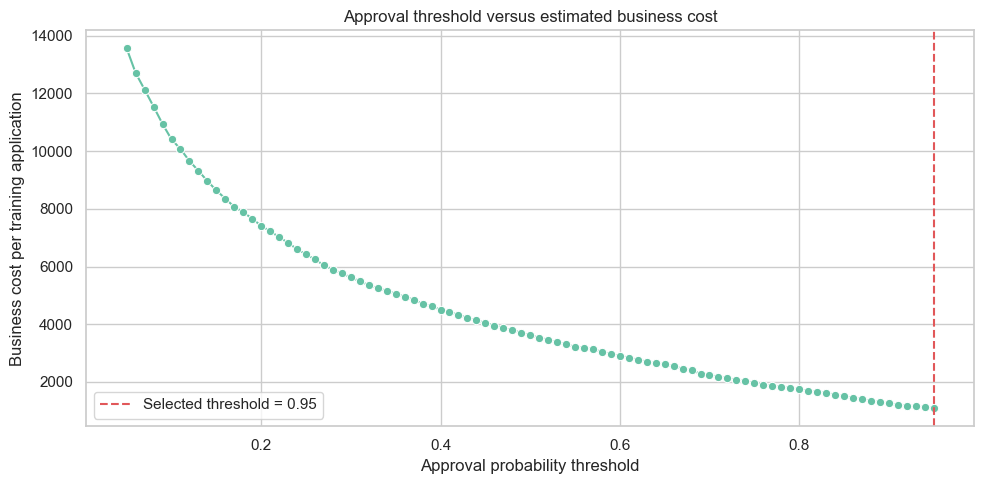

In [17]:
best_model = grid_search.best_estimator_

train_probabilities = best_model.predict_proba(X_train)[:, 1]
thresholds = np.round(np.linspace(0.05, 0.95, 91), 2)
threshold_rows = []

for threshold in thresholds:
    train_predictions = (train_probabilities >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "business_cost_per_app": business_cost(y_train, train_predictions) / len(y_train),
        "precision": precision_score(y_train, train_predictions, zero_division=0),
        "recall": recall_score(y_train, train_predictions, zero_division=0),
        "f1": f1_score(y_train, train_predictions, zero_division=0),
    })

threshold_table = pd.DataFrame(threshold_rows)
optimal_threshold = threshold_table.loc[threshold_table["business_cost_per_app"].idxmin(), "threshold"]
print(f"Cost-minimizing threshold on training data: {optimal_threshold:.2f}")
display(threshold_table.sort_values("business_cost_per_app").head(10))

plt.figure(figsize=(10, 5))
sns.lineplot(data=threshold_table, x="threshold", y="business_cost_per_app", marker="o")
plt.axvline(optimal_threshold, color="#E15759", linestyle="--", label=f"Selected threshold = {optimal_threshold:.2f}")
plt.title("Approval threshold versus estimated business cost")
plt.xlabel("Approval probability threshold")
plt.ylabel("Business cost per training application")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Evaluation and Conclusion

The test set was held out until final evaluation. I report performance at the standard 0.50 threshold and at the cost-sensitive threshold selected on the training data. The cost-sensitive threshold intentionally approves fewer applicants, which reduces false approvals and lowers expected dollar loss under the business assumptions.

In [18]:
def evaluate_at_threshold(model, X_eval, y_eval, threshold):
    probabilities = model.predict_proba(X_eval)[:, 1]
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_eval, predictions, labels=[0, 1]).ravel()
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_eval, predictions),
        "precision": precision_score(y_eval, predictions, zero_division=0),
        "recall": recall_score(y_eval, predictions, zero_division=0),
        "f1": f1_score(y_eval, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, probabilities),
        "true_denials": tn,
        "false_approvals": fp,
        "false_denials": fn,
        "true_approvals": tp,
        "business_cost_total": business_cost(y_eval, predictions),
        "business_cost_per_app": business_cost(y_eval, predictions) / len(y_eval),
    }

evaluation = pd.DataFrame([
    evaluate_at_threshold(best_model, X_test, y_test, 0.50),
    evaluate_at_threshold(best_model, X_test, y_test, float(optimal_threshold)),
])
display(evaluation)

,threshold,accuracy,precision,recall,f1,roc_auc,true_denials,false_approvals,false_denials,true_approvals,business_cost_total,business_cost_per_app
0,0.50,0.90800,0.753012,0.915272,0.826251,0.973633,2757,287,81,875,14998000,3749.5
1,0.95,0.90275,0.955056,0.622385,0.753642,0.973633,3016,28,361,595,4288000,1072.0


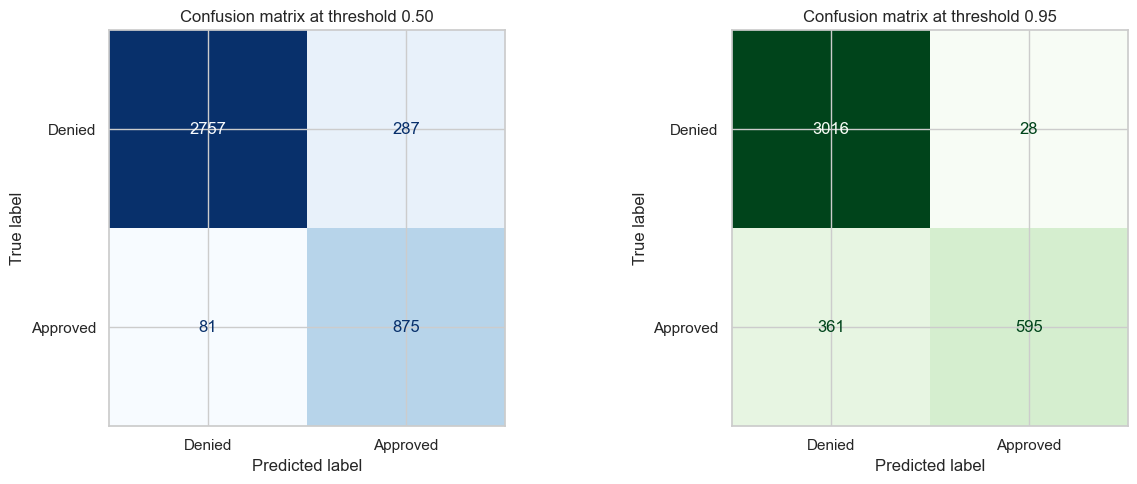

In [19]:
test_probabilities = best_model.predict_proba(X_test)[:, 1]
standard_predictions = (test_probabilities >= 0.50).astype(int)
cost_sensitive_predictions = (test_probabilities >= optimal_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    standard_predictions,
    display_labels=["Denied", "Approved"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Confusion matrix at threshold 0.50")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    cost_sensitive_predictions,
    display_labels=["Denied", "Approved"],
    cmap="Greens",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title(f"Confusion matrix at threshold {optimal_threshold:.2f}")
plt.tight_layout()
plt.show()

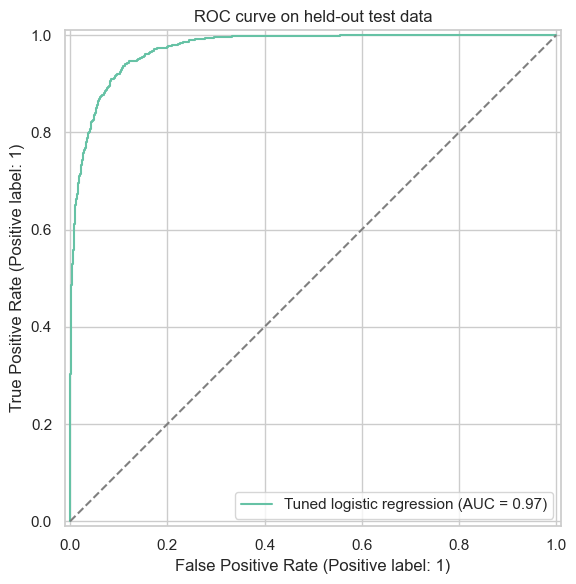

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, test_probabilities, ax=ax, name="Tuned logistic regression")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC curve on held-out test data")
plt.tight_layout()
plt.show()

In [21]:
segment_rows = []
segment_features = ["EmploymentStatus", "EducationLevel", "HomeOwnershipStatus", "BankruptcyHistory"]
test_frame = X_test.copy()
test_frame["actual"] = y_test.values
test_frame["predicted"] = cost_sensitive_predictions
test_frame["probability"] = test_probabilities

for feature in segment_features:
    for value, group in test_frame.groupby(feature, dropna=False):
        if len(group) < 50:
            continue
        segment_rows.append({
            "segment_feature": feature,
            "segment_value": value,
            "n": len(group),
            "actual_approval_rate": group["actual"].mean(),
            "predicted_approval_rate": group["predicted"].mean(),
            "precision": precision_score(group["actual"], group["predicted"], zero_division=0),
            "recall": recall_score(group["actual"], group["predicted"], zero_division=0),
            "business_cost_per_app": business_cost(group["actual"], group["predicted"]) / len(group),
        })

segment_performance = pd.DataFrame(segment_rows).sort_values("business_cost_per_app", ascending=False)
display(segment_performance.head(20))

,segment_feature,segment_value,n,actual_approval_rate,predicted_approval_rate,precision,recall,business_cost_per_app
5,EducationLevel,Doctorate,156,0.442308,0.378205,0.932203,0.797101,2000.000000
7,EducationLevel,Master,620,0.377419,0.269355,0.970060,0.692308,1332.258065
10,HomeOwnershipStatus,Other,415,0.173494,0.115663,0.875000,0.583333,1301.204819
4,EducationLevel,Bachelor,1163,0.279450,0.171109,0.959799,0.587692,1265.692175
1,EmploymentStatus,Self-Employed,311,0.263666,0.176849,0.945455,0.634146,1254.019293
13,BankruptcyHistory,No,3777,0.245698,0.160445,0.953795,0.622845,1111.993646
2,EmploymentStatus,Unemployed,287,0.174216,0.114983,0.909091,0.600000,1080.139373
9,HomeOwnershipStatus,Mortgage,1624,0.249384,0.155788,0.964427,0.602469,1070.197044
3,EducationLevel,Associate,782,0.207161,0.120205,0.946809,0.549383,1066.496164
0,EmploymentStatus,Employed,3402,0.242210,0.157260,0.958879,0.622573,1054.673721


,feature,coefficient,absolute_coefficient
19,numeric__MonthlyIncome,4.317820,4.317820
40,categorical__BankruptcyHistory_Yes,-3.888427,3.888427
4,numeric__LoanAmount,-2.941573,2.941573
29,categorical__EducationLevel_High School,-1.882945,1.882945
25,categorical__EmploymentStatus_Unemployed,-1.535778,1.535778
26,categorical__EducationLevel_Associate,-1.211739,1.211739
22,numeric__NetWorth,1.093405,1.093405
14,numeric__LengthOfCreditHistory,0.898893,0.898893
27,categorical__EducationLevel_Bachelor,-0.885893,0.885893
28,categorical__EducationLevel_Doctorate,0.866310,0.866310


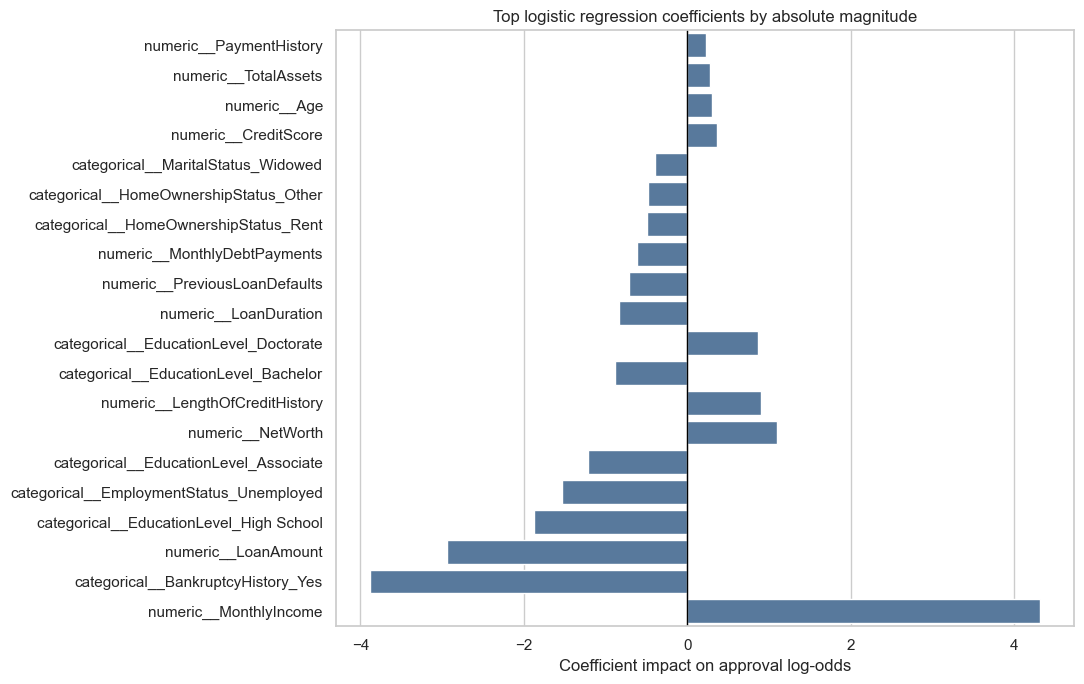

In [22]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = best_model.named_steps["model"].coef_[0]
importance = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients,
        "absolute_coefficient": np.abs(coefficients),
    })
    .sort_values("absolute_coefficient", ascending=False)
    .head(20)
)
display(importance)

plt.figure(figsize=(11, 7))
sns.barplot(data=importance.sort_values("absolute_coefficient"), x="coefficient", y="feature", color="#4C78A8")
plt.axvline(0, color="black", linewidth=1)
plt.title("Top logistic regression coefficients by absolute magnitude")
plt.xlabel("Coefficient impact on approval log-odds")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Final Findings

The tuned logistic regression pipeline is a strong candidate for decision support. It achieves high ROC-AUC on the held-out test set, meaning it ranks approvable applicants well across thresholds. The model's default 0.50 threshold catches many good approvals but allows more false approvals. Because the business assigns a $50,000 cost to false approvals and an $8,000 cost to false denials, the cost-sensitive threshold is the better operating point for an automated screen.

Feature interpretation shows that credit behavior, debt burden, income capacity, prior defaults, and asset/net-worth indicators are among the most influential drivers. This aligns with the business intuition that repayment capacity and credit history should dominate the first-pass decision.

### Business Recommendations

1. Deploy the model as a decision-support score first, not as a fully autonomous approval engine. Applications near the threshold should be routed to manual review.
2. Use the cost-sensitive threshold when the goal is to minimize expected losses. Consider a lower threshold only for campaigns where growth is prioritized over credit risk.
3. Monitor false approvals and false denials monthly, and recalibrate the threshold when realized default/profit outcomes become available.
4. Track segment-level performance for employment, education, home ownership, and bankruptcy-history groups to identify potential fairness or service-quality concerns.
5. Avoid using post-decision variables or derived risk scores as predictors in production unless they are genuinely available before the approval decision.

### Limitations and Improvements

- The target reflects historical approval decisions, not necessarily realized default. A future version should train directly on repayment/default outcomes if available.
- Historical decisions may contain embedded policy or human bias. The model can reproduce those patterns unless fairness reviews and governance checks are added.
- The dollar-cost metric uses average costs supplied by the business. More granular expected profit/loss by loan amount would improve threshold selection.
- Additional tuning could test calibrated probabilities, monotonic models, and engineered affordability features.

### Conclusion

The completed pipeline satisfies the lab objective: it cleans messy data, explores the applicant portfolio, uses reproducible preprocessing, compares multiple algorithms, tunes hyperparameters, evaluates with technical and business metrics, and provides an interpretable final model. The recommended operating strategy is to use the tuned logistic regression model with a cost-sensitive threshold as a first-pass risk screen, supported by manual review and ongoing monitoring.